# Lab 6: Linear Regression Using Gradient Descent

This notebook implements linear regression from scratch with gradient descent on the Student Performance dataset.

It includes:
- data loading
- preprocessing and feature encoding
- train/test split
- gradient descent training
- learning-rate comparison
- loss curve plotting
- evaluation with regression metrics
- a short interpretation of the results


Dataset shape: (395, 33)
Missing values: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Training set shape after preprocessing: (316, 58)
Testing set shape after preprocessing: (79, 58)


,learning_rate,final_train_cost,MSE,RMSE,MAE,R2
1,0.010,1.448340,5.495406,2.344228,1.611895,0.731997
2,0.050,1.411601,5.654383,2.377895,1.644264,0.724244
0,0.001,2.300734,5.866800,2.422148,1.581861,0.713885


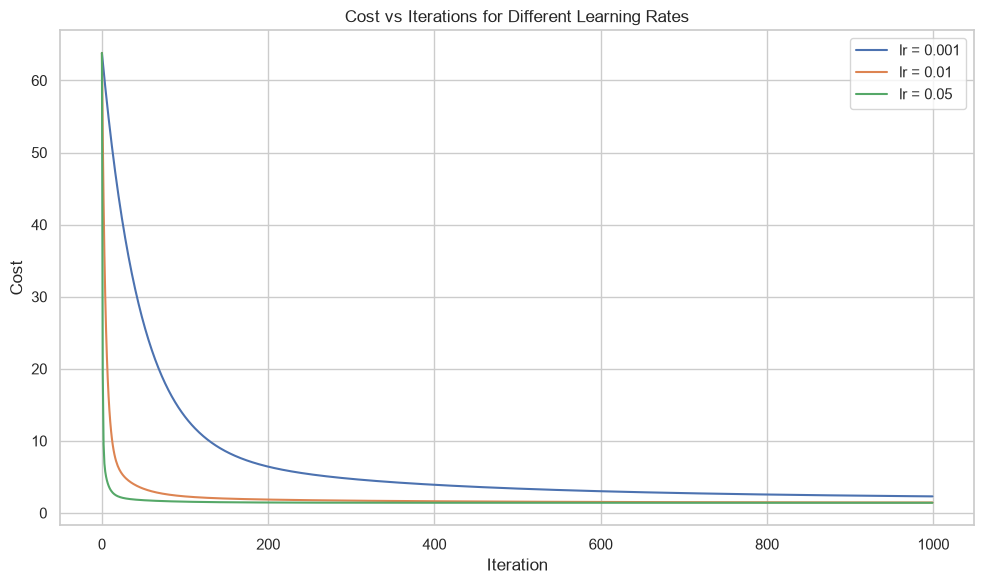

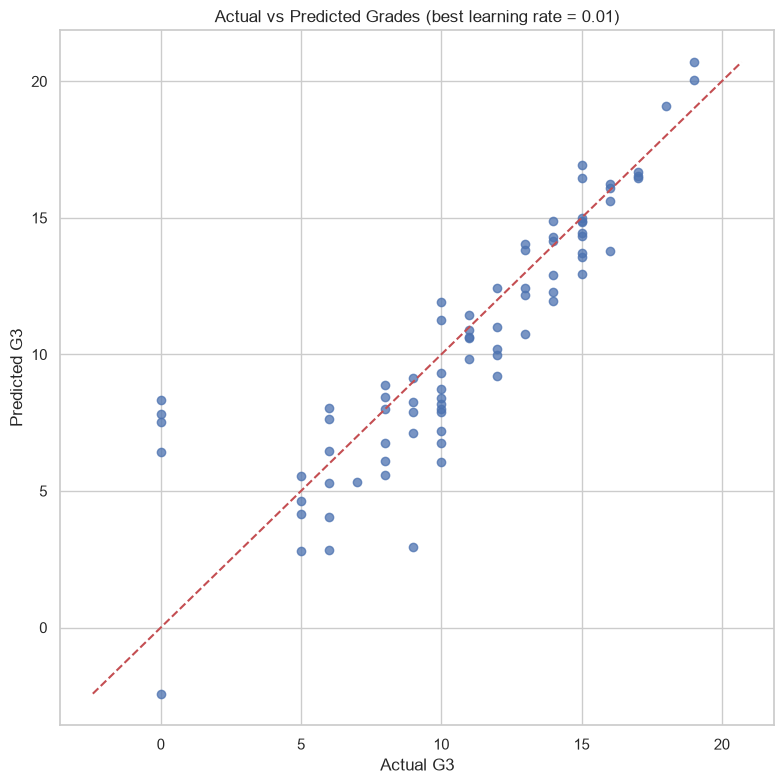

Best learning rate: 0.01
Final training cost: 1.4483
Test MSE:  5.4954
Test RMSE: 2.3442
Test MAE:  1.6119
Test R2:   0.7320

Interpretation:
- Smaller learning rates usually converge more slowly but are more stable.
- A moderate learning rate should reduce the cost smoothly without oscillation.
- The actual-vs-predicted plot shows how close the gradient-descent model is to the ideal diagonal line.
- Use the RMSE, MAE, and R2 values to judge prediction quality on unseen data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
file_path = "student+performance/student/student-mat.csv"
df = pd.read_csv(file_path, sep=";")

print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
display(df.head())

# Select target and features
# G3 is the final grade and is the most suitable regression target for this experiment.
target_column = "G3"
X = df.drop(columns=[target_column])
y = df[target_column].astype(float)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Preprocess numeric and categorical columns separately.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Split first to avoid data leakage.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Training set shape after preprocessing:", X_train.shape)
print("Testing set shape after preprocessing:", X_test.shape)


def add_bias_term(X_matrix: np.ndarray) -> np.ndarray:
    """Add a column of ones to include the intercept term."""
    return np.c_[np.ones((X_matrix.shape[0], 1)), X_matrix]


def compute_cost(X_matrix: np.ndarray, y_vector: np.ndarray, theta: np.ndarray) -> float:
    predictions = X_matrix @ theta
    errors = predictions - y_vector
    return float((errors @ errors) / (2 * len(y_vector)))


def gradient_descent(X_train_matrix: np.ndarray, y_train_vector: np.ndarray, learning_rate: float, iterations: int):
    X_bias = add_bias_term(X_train_matrix)
    y_train_array = np.asarray(y_train_vector, dtype=float)

    theta = np.zeros(X_bias.shape[1])
    losses = []

    for _ in range(iterations):
        predictions = X_bias @ theta
        errors = predictions - y_train_array
        gradient = (X_bias.T @ errors) / len(y_train_array)
        theta -= learning_rate * gradient
        losses.append(float((errors @ errors) / (2 * len(y_train_array))))

        if not np.isfinite(losses[-1]):
            break

    return theta, losses


def predict(X_matrix: np.ndarray, theta: np.ndarray) -> np.ndarray:
    return add_bias_term(X_matrix) @ theta


learning_rates = [0.001, 0.01, 0.05]
iterations = 1000
history = {}
results = []

for lr in learning_rates:
    theta, losses = gradient_descent(X_train, y_train, learning_rate=lr, iterations=iterations)
    history[lr] = {"theta": theta, "losses": losses}

    y_pred = predict(X_test, theta)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "learning_rate": lr,
        "final_train_cost": losses[-1],
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

best_lr = results_df.iloc[0]["learning_rate"]
best_theta = history[best_lr]["theta"]
best_losses = history[best_lr]["losses"]
best_predictions = predict(X_test, best_theta)

# Plot the loss curves for different learning rates.
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(history[lr]["losses"], label=f"lr = {lr}")
plt.title("Cost vs Iterations for Different Learning Rates")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs predicted plot for the best model.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_predictions, alpha=0.75)
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.title(f"Actual vs Predicted Grades (best learning rate = {best_lr})")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.tight_layout()
plt.show()

best_mse = mean_squared_error(y_test, best_predictions)
best_rmse = np.sqrt(best_mse)
best_mae = mean_absolute_error(y_test, best_predictions)
best_r2 = r2_score(y_test, best_predictions)

print(f"Best learning rate: {best_lr}")
print(f"Final training cost: {best_losses[-1]:.4f}")
print(f"Test MSE:  {best_mse:.4f}")
print(f"Test RMSE: {best_rmse:.4f}")
print(f"Test MAE:  {best_mae:.4f}")
print(f"Test R2:   {best_r2:.4f}")

print("\nInterpretation:")
print("- Smaller learning rates usually converge more slowly but are more stable.")
print("- A moderate learning rate should reduce the cost smoothly without oscillation.")
print("- The actual-vs-predicted plot shows how close the gradient-descent model is to the ideal diagonal line.")
print("- Use the RMSE, MAE, and R2 values to judge prediction quality on unseen data.")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
# Load the dataset
file_path = "student+performance/student/student-mat.csv"
df = pd.read_csv(file_path, sep=";")

In [5]:
print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
display(df.head())

Dataset shape: (395, 33)
Missing values: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
# Select target and features
# G3 is the final grade and is the most suitable regression target for this experiment.
target_column = "G3"
X = df.drop(columns=[target_column])
y = df[target_column].astype(float)

In [7]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()


In [8]:
# Preprocess numeric and categorical columns separately.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [9]:
# Split first to avoid data leakage.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Training set shape after preprocessing:", X_train.shape)
print("Testing set shape after preprocessing:", X_test.shape)


Training set shape after preprocessing: (316, 58)
Testing set shape after preprocessing: (79, 58)


In [10]:
def add_bias_term(X_matrix: np.ndarray) -> np.ndarray:
    """Add a column of ones to include the intercept term."""
    return np.c_[np.ones((X_matrix.shape[0], 1)), X_matrix]


In [11]:
def compute_cost(X_matrix: np.ndarray, y_vector: np.ndarray, theta: np.ndarray) -> float:
    predictions = X_matrix @ theta
    errors = predictions - y_vector
    return float((errors @ errors) / (2 * len(y_vector)))


In [12]:
def gradient_descent(X_train_matrix: np.ndarray, y_train_vector: np.ndarray, learning_rate: float, iterations: int):
    X_bias = add_bias_term(X_train_matrix)
    y_train_array = np.asarray(y_train_vector, dtype=float)

    theta = np.zeros(X_bias.shape[1])
    losses = []

    for _ in range(iterations):
        predictions = X_bias @ theta
        errors = predictions - y_train_array
        gradient = (X_bias.T @ errors) / len(y_train_array)
        theta -= learning_rate * gradient
        losses.append(float((errors @ errors) / (2 * len(y_train_array))))

        if not np.isfinite(losses[-1]):
            break

    return theta, losses


def predict(X_matrix: np.ndarray, theta: np.ndarray) -> np.ndarray:
    return add_bias_term(X_matrix) @ theta


learning_rates = [0.001, 0.01, 0.05]
iterations = 1000
history = {}
results = []

for lr in learning_rates:
    theta, losses = gradient_descent(X_train, y_train, learning_rate=lr, iterations=iterations)
    history[lr] = {"theta": theta, "losses": losses}

    y_pred = predict(X_test, theta)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "learning_rate": lr,
        "final_train_cost": losses[-1],
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

,learning_rate,final_train_cost,MSE,RMSE,MAE,R2
1,0.010,1.448340,5.495406,2.344228,1.611895,0.731997
2,0.050,1.411601,5.654383,2.377895,1.644264,0.724244
0,0.001,2.300734,5.866800,2.422148,1.581861,0.713885


In [13]:
best_lr = results_df.iloc[0]["learning_rate"]
best_theta = history[best_lr]["theta"]
best_losses = history[best_lr]["losses"]
best_predictions = predict(X_test, best_theta)

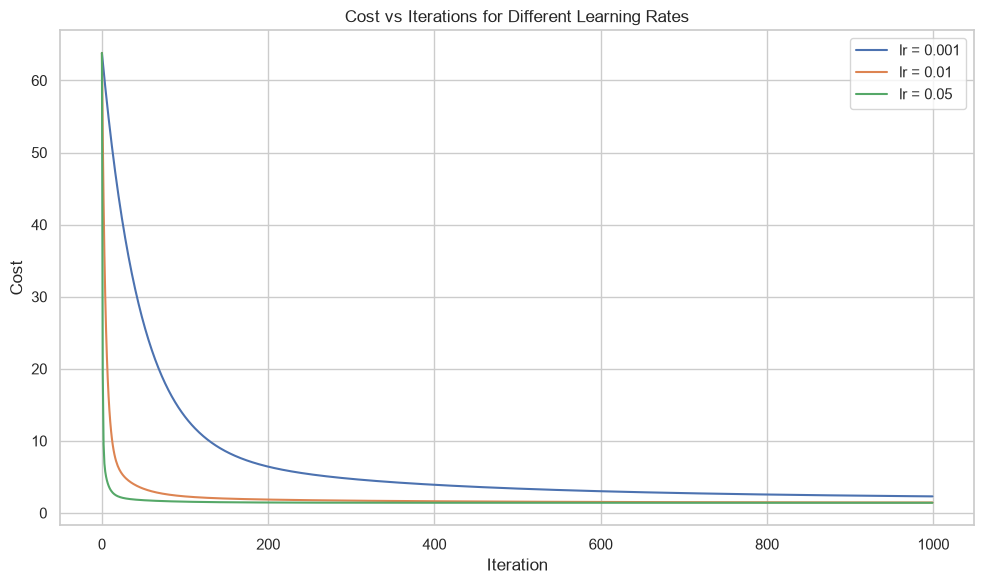

In [14]:
# Plot the loss curves for different learning rates.
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(history[lr]["losses"], label=f"lr = {lr}")
plt.title("Cost vs Iterations for Different Learning Rates")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.tight_layout()
plt.show()

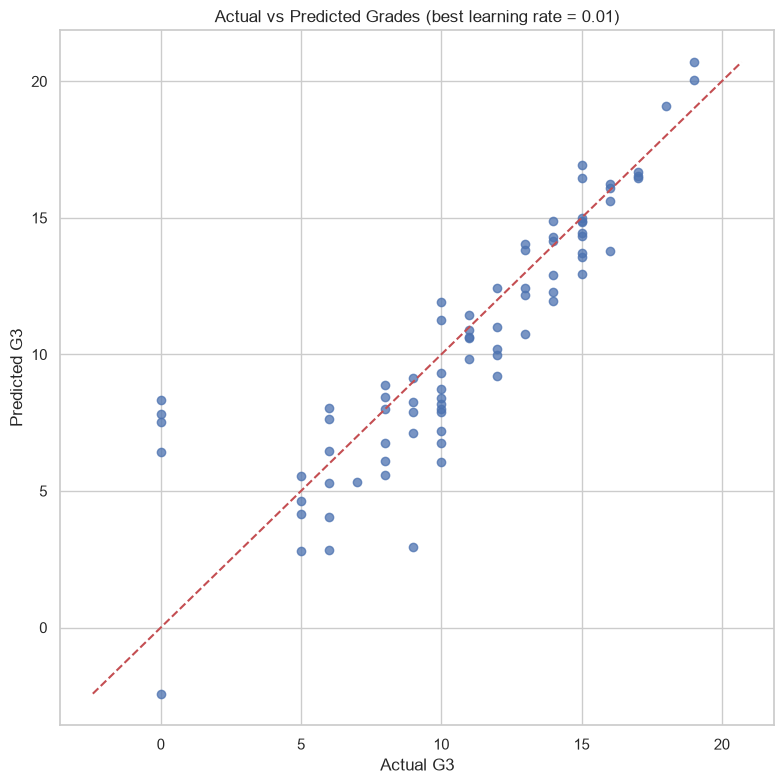

In [15]:
# Actual vs predicted plot for the best model.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_predictions, alpha=0.75)
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.title(f"Actual vs Predicted Grades (best learning rate = {best_lr})")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.tight_layout()
plt.show()